# Student Study Time and Mathematics Performance

## Research Question

Is weekly study time associated with students' final mathematics grade?

## Dataset

UCI Student Performance Mathematics dataset.

- Predictor: `studytime`
- Outcome: `G3`
- Sample: Students with valid `studytime` and `G3` values

In [2]:
import pandas as pd
from scipy.stats import kruskal, spearmanr

# Load the dataset
data = pd.read_csv("../raw/student-mat.csv", sep=";")

# Keep required variables
data = data[["studytime", "G3"]].dropna()

# Create groups
groups = [
    group["G3"].values
    for _, group in data.groupby("studytime")
]

# Kruskal-Wallis test
kw_stat, kw_p = kruskal(*groups)

# Spearman correlation
rho, spearman_p = spearmanr(
    data["studytime"],
    data["G3"]
)

print("Kruskal-Wallis H statistic:", round(kw_stat, 4))
print("Kruskal-Wallis p-value:", round(kw_p, 4))
print("Spearman correlation:", round(rho, 4))
print("Spearman p-value:", round(spearman_p, 4))
# Effect size: epsilon-squared for Kruskal-Wallis
n = len(data)
k = data["studytime"].nunique()

epsilon_squared = (kw_stat - k + 1) / (n - k)

print("Epsilon-squared effect size:", round(epsilon_squared, 4))

Kruskal-Wallis H statistic: 7.5789
Kruskal-Wallis p-value: 0.0556
Spearman correlation: 0.1052
Spearman p-value: 0.0367
Epsilon-squared effect size: 0.0117


<Figure size 800x500 with 0 Axes>

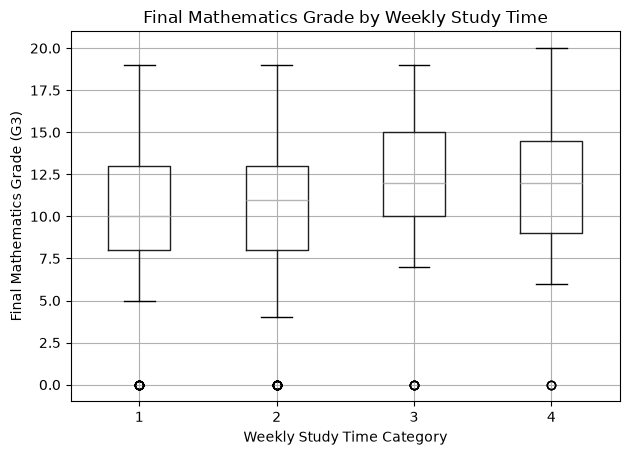

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
data.boxplot(column="G3", by="studytime")

plt.title("Final Mathematics Grade by Weekly Study Time")
plt.suptitle("")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Mathematics Grade (G3)")
plt.tight_layout()

plt.show()